# A1 — Conferência da carga patrimonial

**Pergunta de negócio:** onde a planilha de conferência de carga não bate com o cadastro, que tipo de erro aparece e onde os erros se concentram?

Na rotina real, a carga patrimonial é conferida numa planilha: uma linha por material, com número de patrimônio (BMP), nomenclatura, número de série, local e situação. Os problemas típicos são o mesmo item escrito de vários jeitos, BMP em branco ou digitado errado, série repetida, local escrito de várias formas e, o mais grave, material que a planilha diz estar no lugar mas está com alguém.

**Como a conferência funciona:**
1. A planilha entra no banco como veio, em texto (`staging.carga_planilha`).
2. A view `analise.vw_conferencia_planilha` (SQL, migração `0006`) cruza cada linha com o cadastro (`core`) e marca um tipo de problema por coluna: nome normalizado (sem acento, abreviações por extenso), similaridade de trigramas (`pg_trgm`) para digitação, distância de Levenshtein (`fuzzystrmatch`) para BMP com dígito trocado, e o estado atual da unidade para divergências com o histórico.
3. Este notebook lê o resultado, mostra onde os problemas estão, monta a planilha corrigida e mede o acerto da conferência contra o gabarito do gerador.

> Dados 100% fictícios, gerados em Python (semente 42, período de 01/09/2025 a 31/08/2026). O gabarito só é usado na última seção, para medir o acerto.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from almox.analise import conferencia as a1
from almox.banco import engine
from almox.config import carregar_config_banco

pd.set_option("display.width", 160)
banco = engine(carregar_config_banco())
conferencia = a1.ler_conferencia(banco)
deteccoes = a1.deteccoes(conferencia)
# "Sem BMP porque é recém-adquirido" é detectado, mas NÃO é problema: a planilha
# está certa (o item aguarda tombamento). Fica fora das contagens de problema.
problemas = deteccoes[deteccoes.tipo_erro != "bmp_ausente_legitimo"]
print(
    f"{len(conferencia)} linhas na planilha; "
    f"{problemas.linha.nunique()} com algum problema "
    f"({problemas.linha.nunique() / len(conferencia):.1%})."
)

358 linhas na planilha; 171 com algum problema (47.8%).


## 1. Que tipo de problema aparece

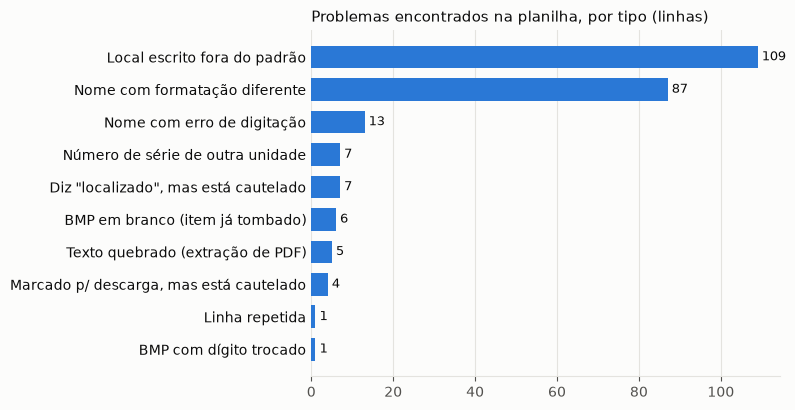

In [2]:
# Estilo dos gráficos: fundo claro, grade discreta, texto em tinta neutra.
COR = {
    "serie": "#2a78d6",
    "contexto": "#8f8e89",
    "fundo": "#fcfcfb",
    "texto": "#0b0b0b",
    "texto2": "#52514e",
    "grade": "#e4e3df",
}
plt.rcParams.update(
    {
        "figure.facecolor": COR["fundo"],
        "axes.facecolor": COR["fundo"],
        "axes.edgecolor": COR["grade"],
        "axes.labelcolor": COR["texto2"],
        "xtick.color": COR["texto2"],
        "ytick.color": COR["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "font.size": 10,
    }
)

NOMES = {
    "local_variante": "Local escrito fora do padrão",
    "nomenclatura_variante": "Nome com formatação diferente",
    "digitacao": "Nome com erro de digitação",
    "divergencia_historico": 'Diz "localizado", mas está cautelado',
    "serie_duplicada": "Número de série de outra unidade",
    "bmp_ausente_erro": "BMP em branco (item já tombado)",
    "artefato_extracao": "Texto quebrado (extração de PDF)",
    "baixa_com_detentor": "Marcado p/ descarga, mas está cautelado",
    "linha_duplicada": "Linha repetida",
    "bmp_digito_trocado": "BMP com dígito trocado",
}
contagem = problemas.tipo_erro.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.2))
barras = ax.barh(
    [NOMES[t] for t in contagem.index], contagem.values, height=0.7, color=COR["serie"]
)
ax.bar_label(barras, padding=3, color=COR["texto"], fontsize=9)
ax.set_title(
    "Problemas encontrados na planilha, por tipo (linhas)",
    loc="left",
    color=COR["texto"],
    fontsize=11,
)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

In [3]:
FORMA = {"local_variante", "nomenclatura_variante", "digitacao", "artefato_extracao"}
tipos_por_linha = problemas.groupby("linha").tipo_erro.agg(set)
so_forma = tipos_por_linha.apply(lambda tipos: tipos <= FORMA)
print(f"Só problema de forma (corrigível automaticamente): {so_forma.sum()} linhas")
print(f"Problema que exige ação humana: {(~so_forma).sum()} linhas")

Só problema de forma (corrigível automaticamente): 146 linhas
Problema que exige ação humana: 25 linhas


## 2. Onde os problemas se concentram

In [4]:
linhas = conferencia.assign(
    problemas=conferencia.linha.map(problemas.linha.value_counts()).fillna(0)
)
por_local = linhas.groupby("local_no_cadastro").agg(
    linhas=("linha", "size"),
    linhas_com_problema=("problemas", lambda s: int((s > 0).sum())),
    problemas=("problemas", "sum"),
)
por_local["% das linhas do local com problema"] = (
    100 * por_local.linhas_com_problema / por_local.linhas
).round(1)
por_local["% das linhas da planilha"] = (100 * por_local.linhas / por_local.linhas.sum()).round(1)
por_local["% dos problemas"] = (100 * por_local.problemas / por_local.problemas.sum()).round(1)
por_local = por_local.sort_values("% das linhas do local com problema")
por_local

,linhas,linhas_com_problema,problemas,% das linhas do local com problema,% das linhas da planilha,% dos problemas
local_no_cadastro,,,,,,
Sala de Informática,11,2,2.0,18.2,3.2,0.9
Instalações Administrativas,100,35,40.0,35.0,28.7,17.9
Reserva de Equipamentos,93,35,38.0,37.6,26.6,17.0
Área de Apoio,54,21,25.0,38.9,15.5,11.2
Sala de Ferramentas,37,18,20.0,48.6,10.6,9.0
Depósito Central,54,53,98.0,98.1,15.5,43.9


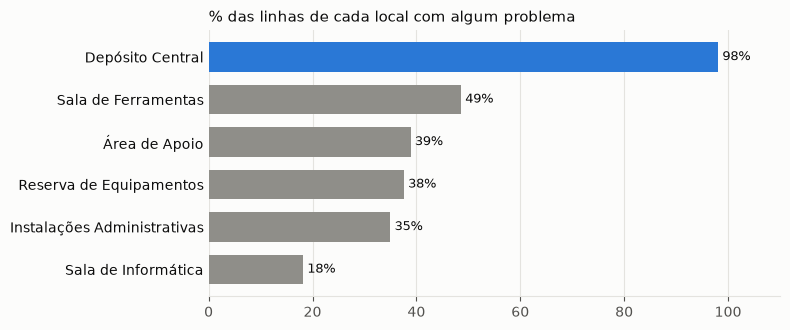

In [5]:
destaque = "Depósito Central"
taxa = por_local["% das linhas do local com problema"]
fig, ax = plt.subplots(figsize=(8, 3.4))
cores = [COR["serie"] if local == destaque else COR["contexto"] for local in taxa.index]
barras = ax.barh(taxa.index, taxa.values, height=0.7, color=cores)
ax.bar_label(
    barras, labels=[f"{v:.0f}%" for v in taxa.values], padding=3, color=COR["texto"], fontsize=9
)
ax.set_title(
    "% das linhas de cada local com algum problema", loc="left", color=COR["texto"], fontsize=11
)
ax.set_xlim(0, 110)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

## 3. Os casos que exigem ação: planilha x histórico

In [6]:
graves = conferencia[conferencia.divergencia_historico | conferencia.baixa_com_detentor]
graves[
    ["linha", "nome_correto", "bmp", "situacao", "status_no_cadastro", "detentor_no_cadastro"]
].rename(
    columns={
        "nome_correto": "material",
        "situacao": "planilha diz",
        "status_no_cadastro": "histórico diz",
        "detentor_no_cadastro": "está com",
    }
)

,linha,material,bmp,planilha diz,histórico diz,está com
46,47,Furadeira de impacto 800 W,5079120,LOCALIZADO,CAUTELADA,Tatiane Siqueira
50,51,Furadeira de impacto 800 W,5454402,LOCALIZADO,CAUTELADA,André Oliveira
57,58,Parafusadeira a bateria 12 V,5058627,LOCALIZADO,CAUTELADA,Heitor Cavalcanti
61,62,Parafusadeira a bateria 12 V,5534215,LOCALIZADO,CAUTELADA,Karina Queiroz
62,63,Parafusadeira a bateria 12 V,5534216,DESCARGA,CAUTELADA,Enzo Torres
71,72,Caixa de ferramentas 65 peças,5818458,LOCALIZADO,CAUTELADA,Enzo Torres
80,81,Lanterna tática recarregável,5071032,DESCARGA,CAUTELADA,Bruno Esteves
91,92,Notebook de serviço,5840545,LOCALIZADO,CAUTELADA,Gustavo Valença
235,236,Rádio portátil VHF RP-100,5051760,DESCARGA,CAUTELADA,Karina Rego
270,271,Rádio portátil VHF digital RP-200,5786020,LOCALIZADO,CAUTELADA,Priscila Barros


## 4. Planilha corrigida

In [7]:
corrigida = a1.planilha_corrigida(conferencia)
print(
    f"{len(corrigida)} linhas (linhas repetidas removidas); "
    f"{(corrigida.verificar != '').sum()} precisam de verificação humana:"
)
print(corrigida[corrigida.verificar != ""].verificar.value_counts().to_string())
corrigida[corrigida.nomenclatura != corrigida.nome_corrigido].head(8)

357 linhas (linhas repetidas removidas); 24 precisam de verificação humana:
verificar
planilha diz localizado; histórico diz cautelado    7
número de série diferente do cadastro               7
BMP em branco (item já tombado)                     6
marcado para descarga, mas está cautelado           4


,linha,bmp,bmp_corrigido,nomenclatura,nome_corrigido,numero_serie,local,situacao,verificar
0,1,5126191,5126191,carregador de bateria de rádio,Carregador de bateria de rádio,NaN,Reserva de Equipamentos,LOCALIZADO,
2,3,NaN,NaN,Carregador de bateria de rádio,Carregador de bateria de rádio,NaN,Reserva de Equipamentos,LOCALIZADO,BMP em branco (item já tombado)
12,13,5833875,5833875,CARREGADOR DE BATERIA DE RADIO,Carregador de bateria de rádio,NaN,Reserva de Equipamentos,LOCALIZADO,
13,14,5833876,5833876,Carregador de bateria de rádio,Carregador de bateria de rádio,NaN,Reserva de Equipamentos,LOCALIZADO,
15,16,5833878,5833878,carregador de bateria de rádio,Carregador de bateria de rádio,NaN,Reserva de Equipamentos,LOCALIZADO,
22,23,5387330,5387330,Maca de campanha dobravel,Maca de campanha dobrável,NaN,DEPÓSITO CENTRAL,LOCALIZADO,
23,24,5387331,5387331,MACA DE CAMPANHA DOBRÁVEL,Maca de campanha dobrável,NaN,DEPÓSITO CENTRAL,LOCALIZADO,
24,25,5387332,5387332,maca de campanha dobrável,Maca de campanha dobrável,NaN,depósito central,LOCALIZADO,


## 5. A conferência acerta? (avaliação contra o gabarito)

O gerador guardou, para cada linha, que erros foram injetados. Aqui ele é usado pela primeira vez, só para medir o acerto. **Precisão:** das linhas apontadas, quantas tinham o erro. **Revocação:** das linhas com o erro, quantas foram achadas.

In [8]:
a1.avaliar(deteccoes, a1.ler_gabarito(banco))

,padrao,no_gabarito,detectados,acertos,falsos_positivos,nao_encontrados,precisao,revocacao
tipo_erro,,,,,,,,
nomenclatura_variante,P12,87,87,87,0,0,1.0,1.0
artefato_extracao,P13,5,5,5,0,0,1.0,1.0
digitacao,P13,13,13,13,0,0,1.0,1.0
bmp_ausente_erro,P14,6,6,6,0,0,1.0,1.0
bmp_ausente_legitimo,P14,3,3,3,0,0,1.0,1.0
bmp_digito_trocado,P14,1,1,1,0,0,1.0,1.0
linha_duplicada,P15,1,1,1,0,0,1.0,1.0
serie_duplicada,P15,7,7,7,0,0,1.0,1.0
baixa_com_detentor,P16,4,4,4,0,0,1.0,1.0


A mesma view foi avaliada em outras sete sementes do gerador, que as regras nunca tinham visto. Em cerca de 2.900 erros, houve **uma** falha de detecção e **um** falso positivo, nos mesmos dois casos-limite: texto quebrado pela extração combinado com outro erro na mesma palavra (`'campan ia'`, `'p ort.'`). As regras não foram ajustadas para esses dois casos, porque isso seria ajustar ao ruído.

Durante a construção, a avaliação revelou três defeitos que foram corrigidos na regra (e não no número): abreviação expandida sem o ponto (`'2 port as'` virava "portátil"), regras de nome exclusivas entre si (uma linha pode ter dois erros) e o BMP vizinho escolhido só pela distância, quando os BMPs de um lote são consecutivos e o número de série é o que desempata.

## Insights

1. **Quase metade da planilha tem problema, mas pouca coisa exige ação.** São 171 das 358 linhas (47,8%) com algum problema, mas 146 delas são só de forma: local ou nome escrito de outro jeito. A normalização resolve essas sozinha. Sobram 25 linhas com problema além da forma; a planilha corrigida já resolve a linha repetida e o BMP com dígito trocado, e **24 linhas vão para verificação humana**, cada uma com o motivo escrito. É nelas que o esforço de conferência deve ir.
2. **O Depósito Central concentra os erros.** Ele tem 15,5% das linhas e 43,9% dos problemas, e 98% das suas linhas têm algum problema, contra 18% a 49% nos outros locais. Isso aponta para o processo de registro daquele local, e não para erros aleatórios. **Recomendação:** local e nome escolhidos numa lista (sem texto livre) e conferência desse local primeiro.
3. **O risco mais caro está em 11 unidades cauteladas.** Em 7 a planilha diz "localizado", e em 4 diz "descarga", mas o histórico mostra que cada uma está com uma pessoa identificada. Dar baixa numa delas seria baixar material em uso; "encontrá-la" no inventário seria encerrar uma cautela que continua aberta. Cinco das onze são ferramentas elétricas, o que se liga à análise A2 (atrasos na Manutenção).
4. **A conferência pode ser automatizada com segurança.** Precisão e revocação de 100% no conjunto padrão, e duas falhas em cerca de 2.900 erros em sete conjuntos nunca vistos. O que é resolvido automaticamente (forma) fica separado do que vai para verificação humana (divergências), com o motivo escrito em cada linha.